In [1]:
import collections
import pathlib
import matplotlib.pyplot as plt
import mne
import numpy
import pandas

In [2]:
dir_path = pathlib.Path.home()/'OneDrive'/'gamma_control_data'
assert dir_path.exists()

In [3]:
rate_df = pandas.read_csv(dir_path/'correct_rate.csv', index_col=0)
rate_df

,Hit,False Alarm,Correct Reject,Miss,rate
4139,0.833333,0.100000,0.900000,0.166667,0.866667
4072,0.283333,0.300000,0.700000,0.716667,0.491667
4466,0.750000,0.366667,0.633333,0.250000,0.691667
4447,0.616667,0.333333,0.666667,0.383333,0.641667
4221,0.450000,0.400000,0.600000,0.550000,0.525000
4579,0.866667,0.066667,0.933333,0.133333,0.900000
4562,0.633333,0.316667,0.683333,0.366667,0.658333
4572,0.400000,0.300000,0.700000,0.600000,0.550000
4630,0.366667,0.150000,0.850000,0.633333,0.608333
4318,0.400000,0.316667,0.683333,0.600000,0.541667


In [4]:
active_name, passive_name = ['allstandard*-tfr.h5' for cond in ('active', 'passive')]
active_dict, passive_dict = dict(), dict()
for path in dir_path.glob('*/'):
    if path.is_dir() and (path/active_name).exists() and (path/passive_name).exists():
        experiment_id = str(path).split('/')[-1].split('_')[0]
        active_dict[experiment_id] = mne.read_(path/active_name, preload=True, verbose=False)
        passive_dict[experiment_id] = mne.read_epochs(path/passive_name, preload=True, verbose=False)

In [5]:
%%time
verbose = mne.set_log_level(False)

tfr_dict = collections.defaultdict(lambda: collections.defaultdict(dict))
for tfr_path in dir_path.glob('*/allstandard*-tfr.h5'):
    eid = str(tfr_path).split('/')[-2].split('_')[0]
    condition, tfr_type = tfr_path.stem.split('allstandard_')[-1].split('-')[:2]
    print(eid, condition, tfr_type)
    tfr_dict[tfr_type][eid][condition] = mne.time_frequency.read_tfrs(tfr_path)[0]

mne.set_log_level(verbose)

4271 active itc
4271 passive itc
4271 active power
4271 active induced_power
4271 passive induced_power
4271 passive induced_itc
4271 passive power
4271 active induced_itc
4704 active itc
4704 passive itc
4704 active power
4704 active induced_power
4704 passive induced_power
4704 passive induced_itc
4704 passive power
4704 active induced_itc
4126 active itc
4126 passive itc
4126 active power
4126 active induced_power
4126 passive induced_power
4126 passive induced_itc
4126 passive power
4126 active induced_itc
4139 active itc
4139 passive itc
4139 active power
4139 active induced_power
4139 passive induced_power
4139 passive induced_itc
4139 passive power
4139 active induced_itc
4318 active itc
4318 passive itc
4318 active power
4318 active induced_power
4318 passive induced_power
4318 passive induced_itc
4318 passive power
4318 active induced_itc
4699 active itc
4699 passive itc
4699 active power
4699 active induced_power
4699 passive induced_power
4699 passive induced_itc
4699 passiv

In [6]:
for eid, rate in zip(rate_df.index, rate_df['rate']):
    print(eid, rate)

4139 0.8666666666666667
4072 0.4916666666666666
4466 0.6916666666666667
4447 0.6416666666666666
4221 0.525
4579 0.9
4562 0.6583333333333333
4572 0.55
4630 0.6083333333333333
4318 0.5416666666666667
4699 0.6416666666666666
4300 0.8583333333333334
4493 0.9166666666666669
4541 0.5416666666666667
4271 0.9416666666666668
4367 0.9
4126 0.95
4593 0.4916666666666667
4704 0.925
4658 0.4666666666666667


No baseline correction applied
No baseline correction applied
No baseline correction applied
No baseline correction applied
No baseline correction applied
No baseline correction applied
No baseline correction applied
No baseline correction applied
No baseline correction applied
No baseline correction applied
No baseline correction applied
No baseline correction applied
No baseline correction applied
No baseline correction applied
No baseline correction applied
No baseline correction applied
No baseline correction applied
No baseline correction applied
No baseline correction applied
No baseline correction applied
No baseline correction applied
No baseline correction applied
No baseline correction applied
No baseline correction applied
No baseline correction applied
No baseline correction applied
No baseline correction applied
No baseline correction applied
No baseline correction applied
No baseline correction applied
No baseline correction applied
No baseline correction applied
No basel

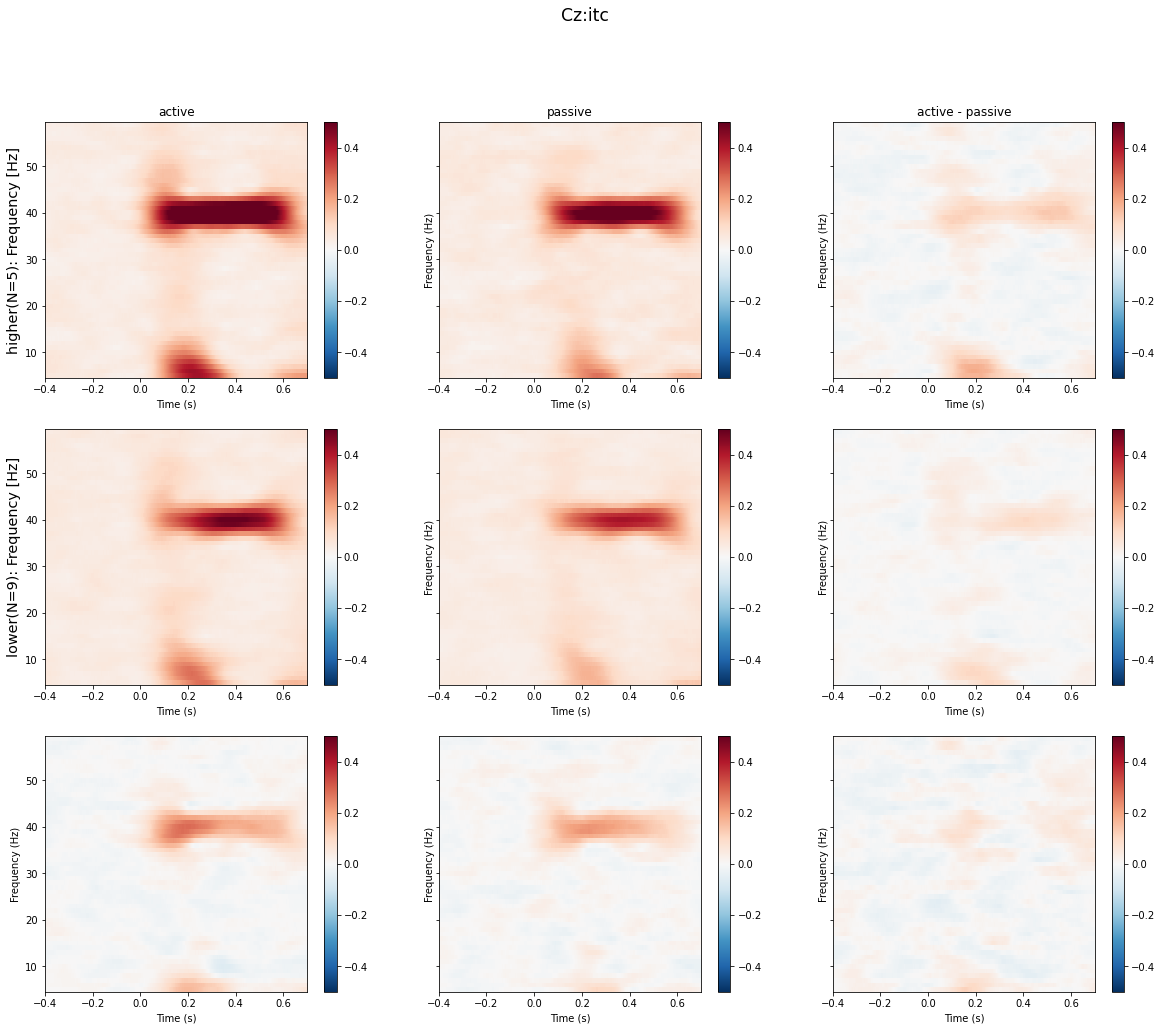

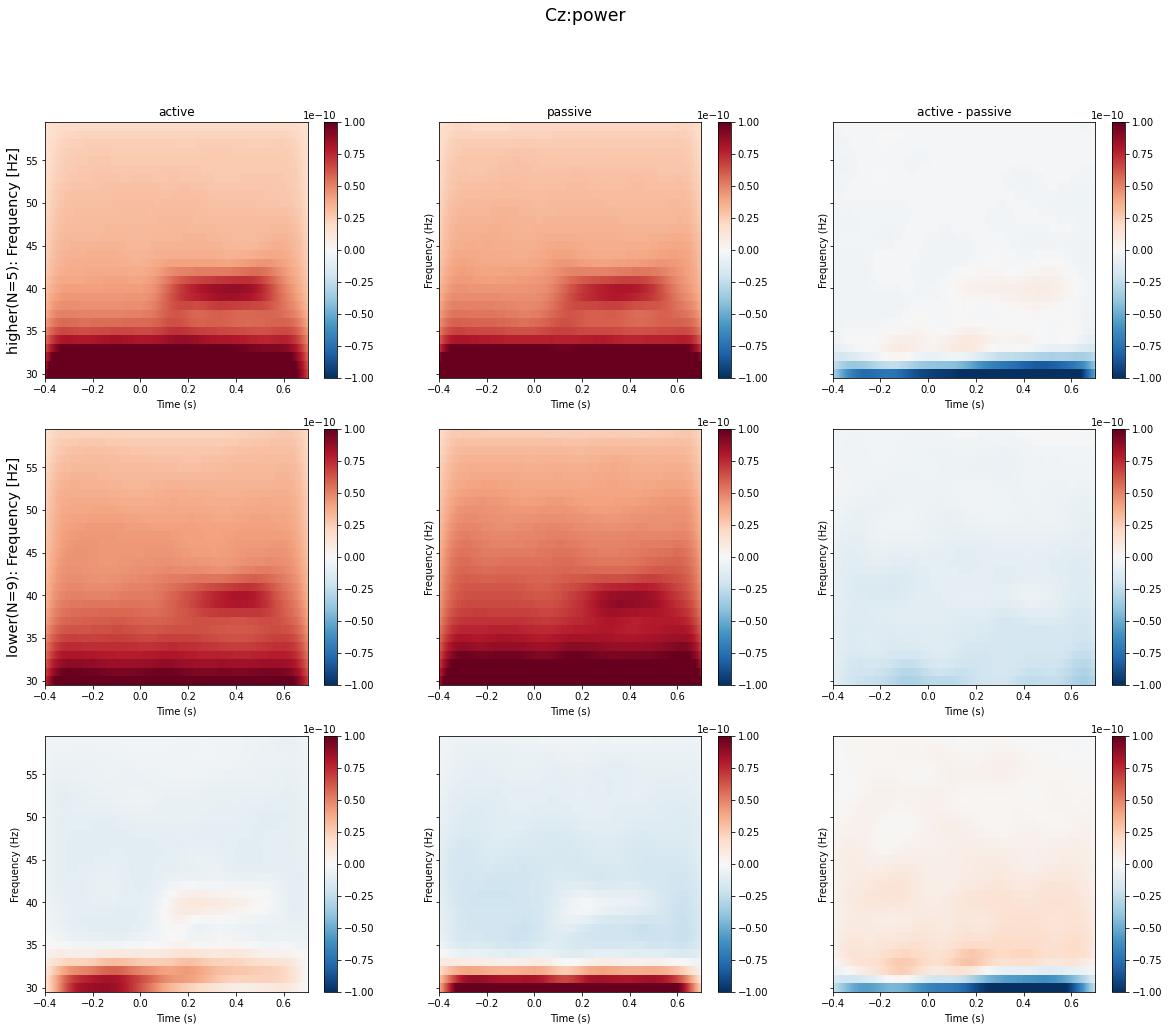

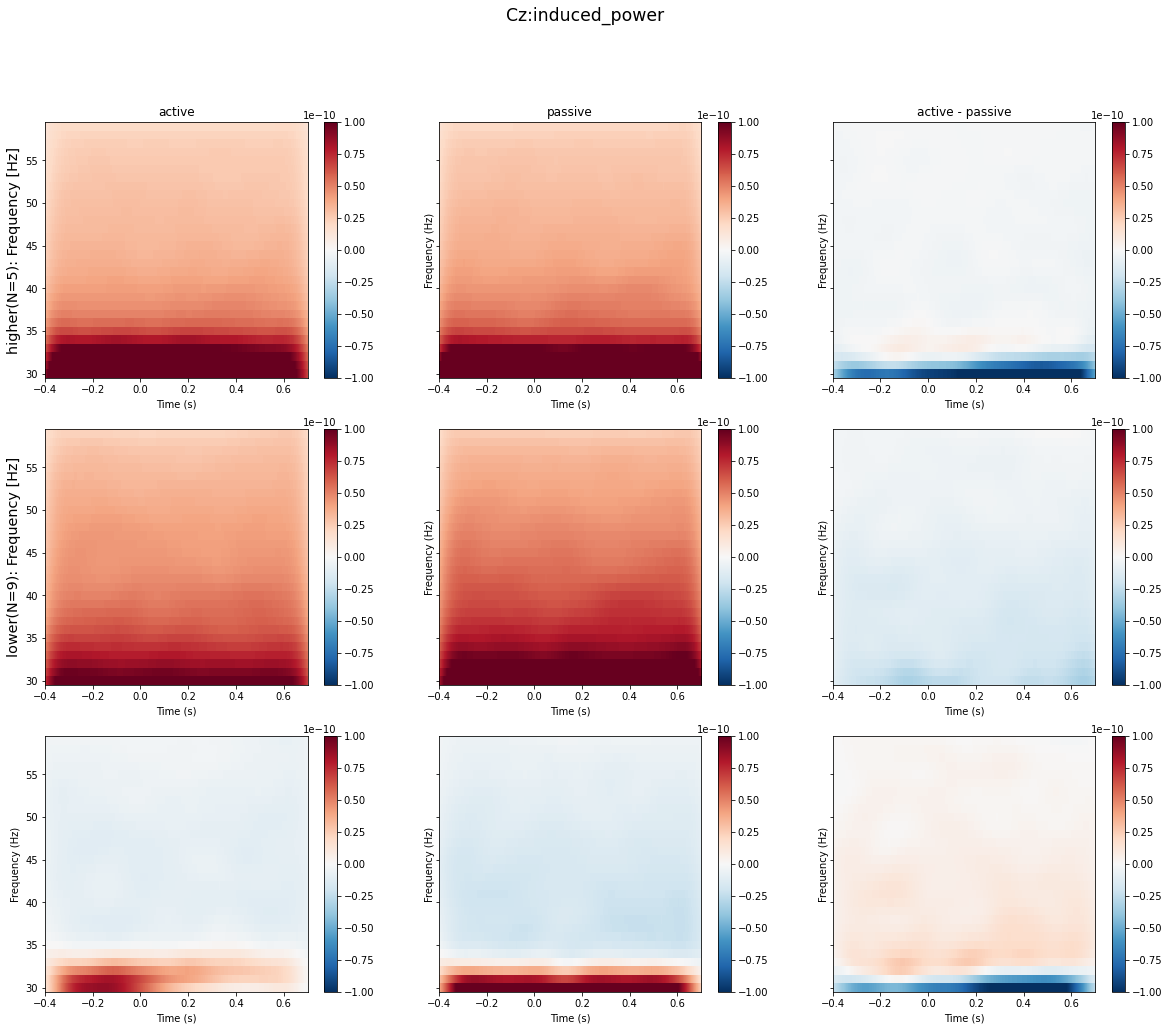

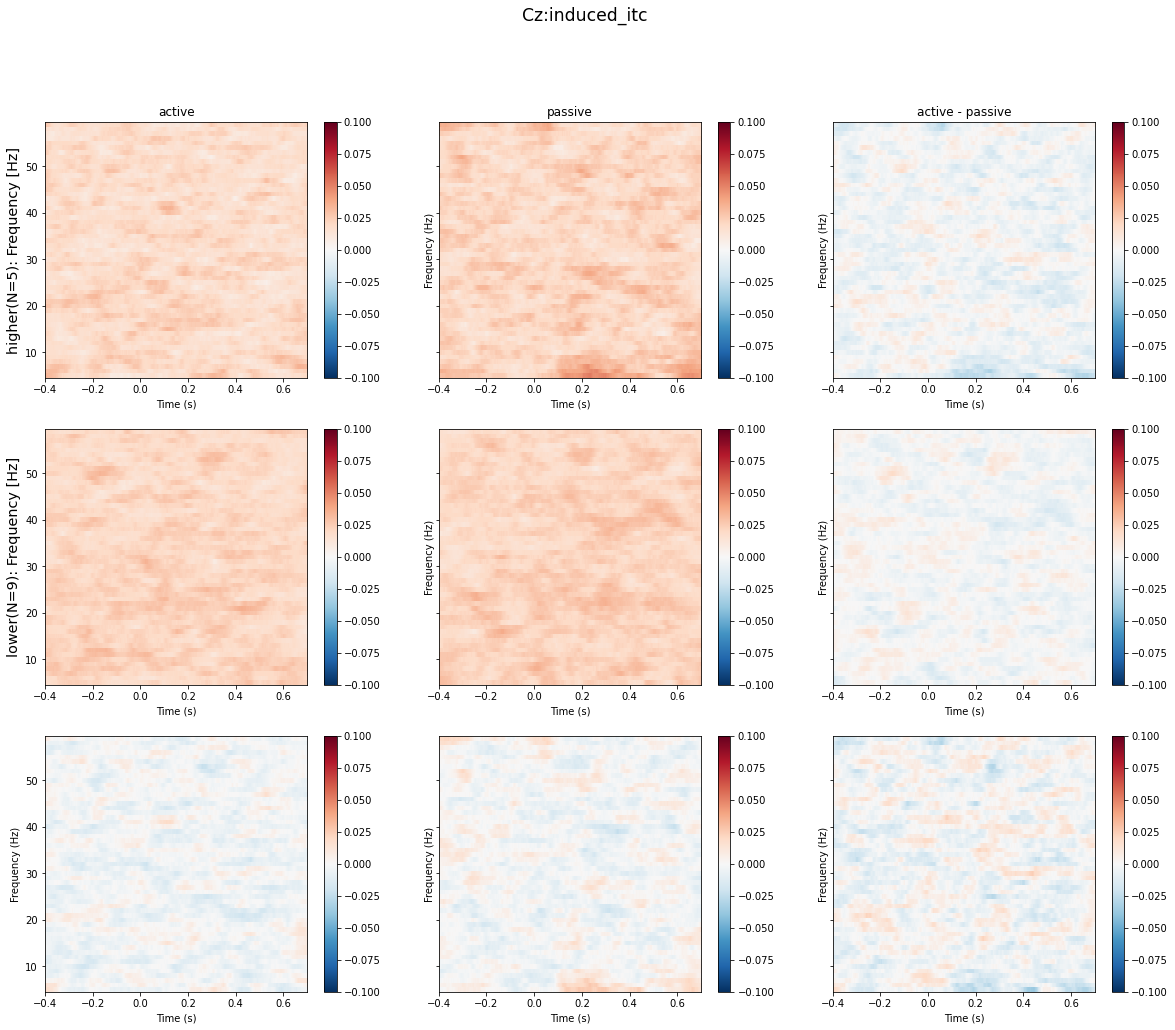

In [7]:
import statistics
import itertools
import functools
criteria = 0.8
channel_name = 'Cz'
plot_keyargs_dict = {
    'power': dict(
        vmin=-1e-10, vmax=1e-10,
        fmin=30,
        show=False
    ),
    'induced_power': dict(
        vmin=-1e-10, vmax=1e-10,
        fmin=30,
        show=False
    ),
    'itc': dict(
        vmin=-0.5, vmax=0.5,
        show=False
    ),
    'induced_itc': dict(
        vmin=-0.1, vmax=0.1,
        show=False
    )
}

for tfr_type, each_tfr_dict in tfr_dict.items():
    fig, axes = plt.subplots(3, 3, sharey=True, figsize=(20, 16))
    condrate_dict = collections.defaultdict(lambda: collections.defaultdict(list))
    for eid, rate in zip(rate_df.index, rate_df['rate']):
        for cond, tfr in each_tfr_dict[str(eid)].items():
            condrate_dict[cond][rate > criteria].append(tfr)
    mean_dict = {
        cond: {
            tf: functools.reduce(lambda x, y: x + y, condrate_dict[cond][tf])/len(condrate_dict[cond][tf]) for tf in [True, False]
        } for cond in ['active', 'passive']
    }
    plot_keyargs = plot_keyargs_dict[tfr_type]
    _ = mean_dict['active'][True].plot(channel_name, axes=axes[0, 0], **plot_keyargs)
    _ = mean_dict['passive'][True].plot(channel_name, axes=axes[0, 1], **plot_keyargs)
    _ = (mean_dict['active'][True] - mean_dict['passive'][True]).plot(channel_name, axes=axes[0, 2], **plot_keyargs)
    _ = mean_dict['active'][False].plot(channel_name, axes=axes[1, 0], **plot_keyargs)
    _ = mean_dict['passive'][False].plot(channel_name, axes=axes[1, 1], **plot_keyargs)
    _ = (mean_dict['active'][False] - mean_dict['passive'][False]).plot(channel_name, axes=axes[1, 2], **plot_keyargs)
    _ = (mean_dict['active'][True] - mean_dict['active'][False]).plot(channel_name, axes=axes[2, 0], **plot_keyargs)
    _ = (mean_dict['passive'][True] - mean_dict['passive'][False]).plot(channel_name, axes=axes[2, 1], **plot_keyargs)
    _ = ((mean_dict['active'][True] - mean_dict['passive'][True]) - (mean_dict['active'][False] - mean_dict['passive'][False])).plot(channel_name, axes=axes[2, 2], **plot_keyargs)

    axes[0, 0].set_title('active')
    axes[0, 1].set_title('passive')
    axes[0, 2].set_title('active - passive')
    axes[0, 0].set_ylabel('higher(N={}): Frequency [Hz]'.format(len(condrate_dict['active'][True])), size='x-large')
    axes[1, 0].set_ylabel('lower(N={}): Frequency [Hz]'.format(len(condrate_dict['active'][False])), size='x-large')

    fig.suptitle(channel_name + ':' + tfr_type, size='xx-large')
    fig.show()